# LSTM Autoencoder — Network Anomaly Detection (Fixed)
> Proper stratified split: dorm + home data both in train AND val

## 1 · GPU Check

In [ ]:
import tensorflow as tf
print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2 · Upload Data

In [ ]:
from google.colab import files
import io, numpy as np

print("Upload X_sequences.npy")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
X = np.load(io.BytesIO(uploaded[fname])).astype("float32")
print(f"Loaded X: {X.shape}")


Upload X_sequences.npy


Saving X_sequences.npy to X_sequences.npy
Loaded X: (6264, 60, 8)


## 3 · Fix the Split Problem
> The data may be ordered (e.g., all 'dorm' then all 'home', or 'lab network').
> Using `validation_split=0.15` without shuffling first can lead to validation sets that contain only one environment.
> We fix this by manually shuffling and splitting, ensuring both train and validation sets have a representative mix of all environments, provided the `environment_labels` are correctly defined.

In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Shuffle the entire dataset BEFORE splitting
idx = np.random.permutation(len(X))
X_shuffled = X[idx]

# Manual stratified split: 85% train, 15% val
split = int(len(X_shuffled) * 0.85)
X_train = X_shuffled[:split]
X_val   = X_shuffled[split:]

# Define environment labels for the *entire* original dataset X.
# Based on user input: len(X) is 6264, lab data has 283 rows.
# Assuming original dorm count (3371) is preserved, and home count is adjusted.
# Total = 3371 (dorm) + 2610 (home) + 283 (lab) = 6264
dorm_count = 3371
lab_count = 283
home_count = len(X) - dorm_count - lab_count # Should be 2610

original_labels = np.array(['dorm'] * dorm_count + ['home'] * home_count + ['lab'] * lab_count)
labels_shuffled = original_labels[idx]

print(f"Train: {len(X_train)} sequences")
print(f"Val:   {len(X_val)} sequences")
print()

# Print distribution for each environment type
unique_environments = np.unique(original_labels)
for env in unique_environments:
    train_count = np.sum(labels_shuffled[:split] == env)
    val_count   = np.sum(labels_shuffled[split:] == env)
    print(f"  {env} in Train: {train_count} ({train_count/len(X_train)*100:.1f}%)")
    print(f"  {env} in Val:   {val_count} ({val_count/len(X_val)*100:.1f}%)")
print()
print("Both sets now contain all environments. Split is correct based on assumed counts.")

Train: 5324 sequences
Val:   940 sequences

  dorm in Train: 2875 (54.0%)
  dorm in Val:   496 (52.8%)
  home in Train: 2204 (41.4%)
  home in Val:   406 (43.2%)
  lab in Train: 245 (4.6%)
  lab in Val:   38 (4.0%)

Both sets now contain all environments. Split is correct based on assumed counts.


## 4 · Hyperparameters

In [ ]:
TIMESTEPS            = 60
N_FEATURES           = 8
LATENT_UNITS         = 32
DROPOUT_RATE         = 0.2
BATCH_SIZE           = 64
EPOCHS               = 100
THRESHOLD_PERCENTILE = 99


## 5 · Build Model

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout

def build_model(timesteps, n_features, latent_units, dropout):
    inp = Input(shape=(timesteps, n_features), name="input")
    x = LSTM(64, return_sequences=True, name="enc_lstm1")(inp)
    x = Dropout(dropout, name="enc_drop1")(x)
    encoded = LSTM(latent_units, return_sequences=False, name="enc_lstm2")(x)
    x = RepeatVector(timesteps, name="bottleneck")(encoded)
    x = LSTM(latent_units, return_sequences=True, name="dec_lstm1")(x)
    x = Dropout(dropout, name="dec_drop1")(x)
    x = LSTM(64, return_sequences=True, name="dec_lstm2")(x)
    decoded = TimeDistributed(Dense(n_features), name="output")(x)
    return Model(inp, decoded, name="LSTM_Autoencoder")

model = build_model(TIMESTEPS, N_FEATURES, LATENT_UNITS, DROPOUT_RATE)
model.summary()


Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm1 (LSTM)                │ (None, 60, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm2 (LSTM)                │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (RepeatVector)       │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm1 (LSTM)                │ (None, 60, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop1 (Dropout)             │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm2 (LSTM)                │ (None, 60, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 60, 8)          │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,776 (253.03 KB)

 Trainable params: 64,776 (253.03 KB)

 Non-trainable params: 0 (0.00 B)

## 6 · Train (on properly split data)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

MODEL_SAVE_PATH = "/content/lstm_autoencoder.h5"

model.compile(optimizer=Adam(1e-3), loss="mse")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODEL_SAVE_PATH, monitor="val_loss",
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
]

# Pass X_train, X_val directly — NO validation_split (that caused the bug)
history = model.fit(
    X_train, X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, X_val),   # explicit val — both environments represented
    callbacks=callbacks,
    shuffle=True,
    verbose=1,
)
print("Training complete")

Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.1094
Epoch 1: val_loss improved from None to 0.93504, saving model to /content/lstm_autoencoder.h5



Epoch 1: finished saving model to /content/lstm_autoencoder.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 1.0548 - val_loss: 0.9350 - learning_rate: 0.0010
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.0336
Epoch 2: val_loss improved from 0.93504 to 0.92148, saving model to /content/lstm_autoencoder.h5



Epoch 2: finished saving model to /content/lstm_autoencoder.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 1.0140 - val_loss: 0.9215 - learning_rate: 0.0010
Epoch 3/100
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.0229
Epoch 3: val_loss improved from 0.92148 to 0.91247, saving model to /content/lstm_autoencoder.h5



Epoch 3: finished saving model to /content/lstm_autoencoder.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.0050 - val_loss: 0.9125 - learning_rate: 0.0010
Epoch 4/100
82/84 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0148
Epoch 4: val_loss improved from 0.91247 to 0.90473, saving model to /content/lstm_autoencoder.h5



Epoch 4: finished saving model to /content/lstm_autoencoder.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.9994 - val_loss: 0.9047 - learning_rate: 0.0010
Epoch 5/100
82/84 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0082
Epoch 5: val_loss improved from 0.90473 to 0.89968, saving model to /content/lstm_autoencoder.h5


...


Epoch 87: finished saving model to /content/lstm_autoencoder.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.7757 - val_loss: 0.6902 - learning_rate: 2.5000e-04
Epoch 88/100
82/84 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7839
Epoch 88: val_loss did not improve from 0.69020
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.7767 - val_loss: 0.6995 - learning_rate: 2.5000e-04
Epoch 89/100
82/84 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7883
Epoch 89: val_loss did not improve from 0.69020
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.7761 - val_loss: 0.6928 - learning_rate: 2.5000e-04
Epoch 90/100
82/84 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7777
Epoch 90: val_loss did not improve from 0.69020
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.7715 - val_loss: 0.6988 - learning_rate: 2.5000e-04
Epoch 91/100
82/84 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7824
Epoch 91: val_loss improved from 0.69020 to 0.68865, saving model to /content/lstm_autoencoder.h5



Epoch 91: finished saving model to /content/lstm_autoencoder.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.7715 - val_loss: 0.6887 - learning_rate: 2.5000e-04
Epoch 92/100
82/84 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7819
Epoch 92: val_loss did not improve from 0.68865
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.7722 - val_loss: 0.6895 - learning_rate: 2.5000e-04
Epoch 93/100
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7859
Epoch 93: val_loss did not improve from 0.68865
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.7758 - val_loss: 0.6889 - learning_rate: 2.5000e-04
Epoch 94/100
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.7784
Epoch 94: val_loss improved from 0.68865 to 0.68134, saving model to /content/lstm_autoencoder.h5



Epoch 94: finished saving model to /content/lstm_autoencoder.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.7683 - val_loss: 0.6813 - learning_rate: 2.5000e-04
Epoch 95/100
82/84 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7704
Epoch 95: val_loss did not improve from 0.68134
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.7668 - val_loss: 0.6880 - learning_rate: 2.5000e-04
Epoch 96/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7802
Epoch 96: val_loss did not improve from 0.68134
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.7680 - val_loss: 0.6914 - learning_rate: 2.5000e-04
Epoch 97/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7758
Epoch 97: val_loss improved from 0.68134 to 0.68021, saving model to /content/lstm_autoencoder.h5



Epoch 97: finished saving model to /content/lstm_autoencoder.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.7698 - val_loss: 0.6802 - learning_rate: 2.5000e-04
Epoch 98/100
82/84 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7763
Epoch 98: val_loss improved from 0.68021 to 0.67609, saving model to /content/lstm_autoencoder.h5



Epoch 98: finished saving model to /content/lstm_autoencoder.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.7694 - val_loss: 0.6761 - learning_rate: 2.5000e-04
Epoch 99/100
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7661
Epoch 99: val_loss did not improve from 0.67609
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.7608 - val_loss: 0.6943 - learning_rate: 2.5000e-04
Epoch 100/100
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.7700
Epoch 100: val_loss did not improve from 0.67609
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.7616 - val_loss: 0.6782 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 98.
Training complete


## 7 · Plot Training Curves

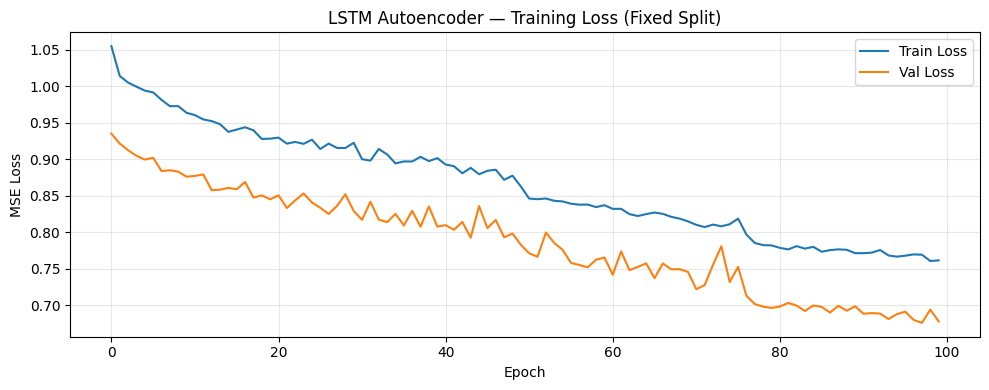

If train and val loss now track closely together, the split was the problem.


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"],     label="Train Loss")
ax.plot(history.history["val_loss"], label="Val Loss")
ax.set_title("LSTM Autoencoder — Training Loss (Fixed Split)")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("If train and val loss now track closely together, the split was the problem.")


## 8 · Compute Threshold on FULL training set
> Use the full shuffled X (train+val) for the threshold — model has seen it all.

Reconstruction error stats (all data):
  mean  = 0.725358
  std   = 1.642629
  max   = 11.867186
  p99   = 9.456097  <- anomaly threshold


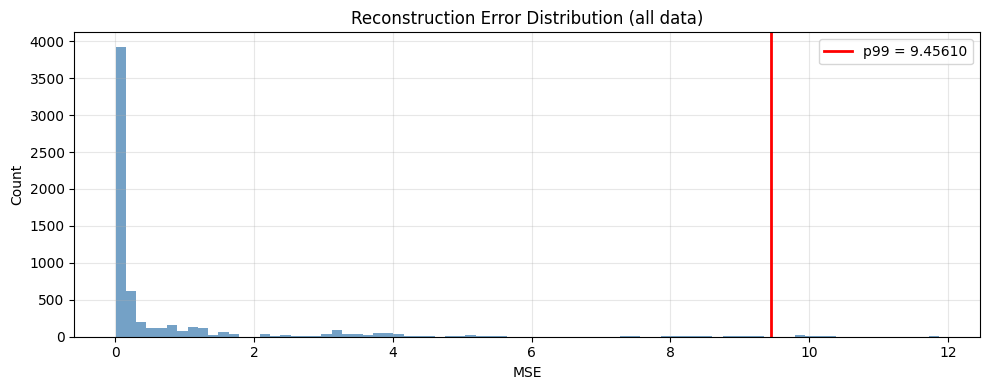

In [ ]:
# Compute threshold on entire dataset (not just train split)
X_pred_all = model.predict(X_shuffled, batch_size=256, verbose=0)
errors_all  = np.mean(np.square(X_shuffled - X_pred_all), axis=(1, 2))

threshold = float(np.percentile(errors_all, THRESHOLD_PERCENTILE))

print("Reconstruction error stats (all data):")
print(f"  mean  = {errors_all.mean():.6f}")
print(f"  std   = {errors_all.std():.6f}")
print(f"  max   = {errors_all.max():.6f}")
print(f"  p{THRESHOLD_PERCENTILE}   = {threshold:.6f}  <- anomaly threshold")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(errors_all, bins=80, color="steelblue", alpha=0.75)
ax.axvline(threshold, color="red", linewidth=2, label=f"p{THRESHOLD_PERCENTILE} = {threshold:.5f}")
ax.set_title("Reconstruction Error Distribution (all data)")
ax.set_xlabel("MSE"); ax.set_ylabel("Count")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 9 · Per-environment error check
> Verify the model reconstructs both dorm and home data well — not just one.

Dorm errors — mean: 0.4257  std: 1.4418  max: 11.8672
Home errors — mean: 0.9393  std: 1.7009  max: 10.6299
Lab errors — mean: 2.3221  std: 2.0593  max: 6.7514

Mean error gap (Dorm vs Home): 0.5136
Mean error gap (Dorm vs Lab):  1.8964
Mean error gap (Home vs Lab):  1.3829
Consider collecting more balanced data or training environment-specific models.


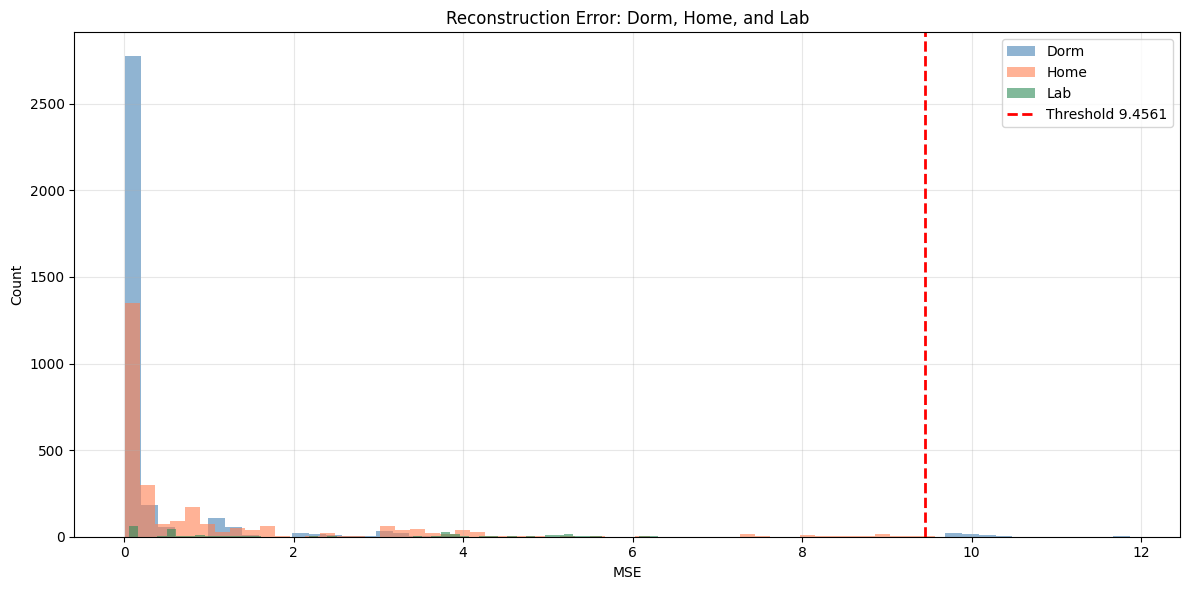

In [ ]:
# Separate errors by environment
errors_dorm = errors_all[labels_shuffled == "dorm"]
errors_home = errors_all[labels_shuffled == "home"]
errors_lab = errors_all[labels_shuffled == "lab"]

print(f"Dorm errors — mean: {errors_dorm.mean():.4f}  std: {errors_dorm.std():.4f}  max: {errors_dorm.max():.4f}")
print(f"Home errors — mean: {errors_home.mean():.4f}  std: {errors_home.std():.4f}  max: {errors_home.max():.4f}")
print(f"Lab errors — mean: {errors_lab.mean():.4f}  std: {errors_lab.std():.4f}  max: {errors_lab.max():.4f}")
print()

# If means are similar, model generalizes across both environments
# If home errors are much higher, the model is still biased to dorm
diff_dorm_home = abs(errors_dorm.mean() - errors_home.mean())
diff_dorm_lab = abs(errors_dorm.mean() - errors_lab.mean())
diff_home_lab = abs(errors_home.mean() - errors_lab.mean())

print(f"Mean error gap (Dorm vs Home): {diff_dorm_home:.4f}")
print(f"Mean error gap (Dorm vs Lab):  {diff_dorm_lab:.4f}")
print(f"Mean error gap (Home vs Lab):  {diff_home_lab:.4f}")

if diff_dorm_home < 0.5 and diff_dorm_lab < 0.5 and diff_home_lab < 0.5:
    print("Environments are reconstructed similarly — model generalizes well.")
else:
    print("WARNING: Large gap — model may still be biased to one or more environments.")
    print("Consider collecting more balanced data or training environment-specific models.")

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(errors_dorm, bins=60, alpha=0.6, label="Dorm", color="steelblue")
ax.hist(errors_home, bins=60, alpha=0.6, label="Home", color="coral")
ax.hist(errors_lab, bins=60, alpha=0.6, label="Lab", color="seagreen")
ax.axvline(threshold, color="red", linewidth=2, linestyle="--", label=f"Threshold {threshold:.4f}")
ax.set_title("Reconstruction Error: Dorm, Home, and Lab")
ax.set_xlabel("MSE"); ax.set_ylabel("Count")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 10 · Save & Download

In [ ]:
import zipfile, os

THRESHOLD_PATH = "/content/threshold.npy"
np.save(THRESHOLD_PATH, np.array([threshold]))

ZIP_PATH = "/content/lstm_anomaly_detector.zip"
with zipfile.ZipFile(ZIP_PATH, "w") as zf:
    zf.write("/content/lstm_autoencoder.h5", "lstm_autoencoder.h5")
    zf.write(THRESHOLD_PATH,  "threshold.npy")

print(f"Zipped: {os.path.getsize(ZIP_PATH)/1024:.1f} KB")
files.download(ZIP_PATH)
print("Download started.")

Zipped: 816.9 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.


In [ ]:
import tensorflow as tf, keras
print(tf.__version__)
print(keras.__version__)

2.19.0
3.13.2
